# Decision Tree Model (No-leakage, With Automatic Tuning)



In [1]:
import os
import sys
import importlib
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

sys.path.append(os.path.abspath('..'))


import src.model_utils as model_utils
importlib.reload(model_utils)

evaluate_classifier = model_utils.evaluate_classifier
get_confusion_matrix_df = model_utils.get_confusion_matrix_df
load_encoded_splits = model_utils.load_encoded_splits
plot_metric_scorecards = model_utils.plot_metric_scorecards
plot_roc_curve = model_utils.plot_roc_curve
run_random_search = model_utils.run_random_search

In [2]:
DATA_DIR = '../data/'
X_train, y_train, X_val, y_val, X_test, y_test = load_encoded_splits(DATA_DIR, version="no-leakage")

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

Splits loaded successfully.
X_train: (60876, 32), y_train: (60876,)
X_val: (13045, 32), y_val: (13045,)
X_test: (13046, 32), y_test: (13046,)
X_train: (60876, 86), y_train: (60876,)
X_val:   (13045, 86), y_val:   (13045,)
X_test:  (13046, 86), y_test:  (13046,)


In [3]:
SEED = 42

base_dt = DecisionTreeClassifier(random_state=SEED)

param_distributions = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.0001, 0.001, 0.01],
}

search = run_random_search(
    estimator=base_dt,
    param_distributions=param_distributions,
    X_train=X_train,
    y_train=y_train,
    n_iter=12,
    cv=3,
    scoring='f1',
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)

best_dt = search.best_estimator_
print('Best params:', search.best_params_)
print(f'Best CV f1: {search.best_score_:.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'entropy', 'ccp_alpha': 0.0001}
Best CV f1: 0.6186


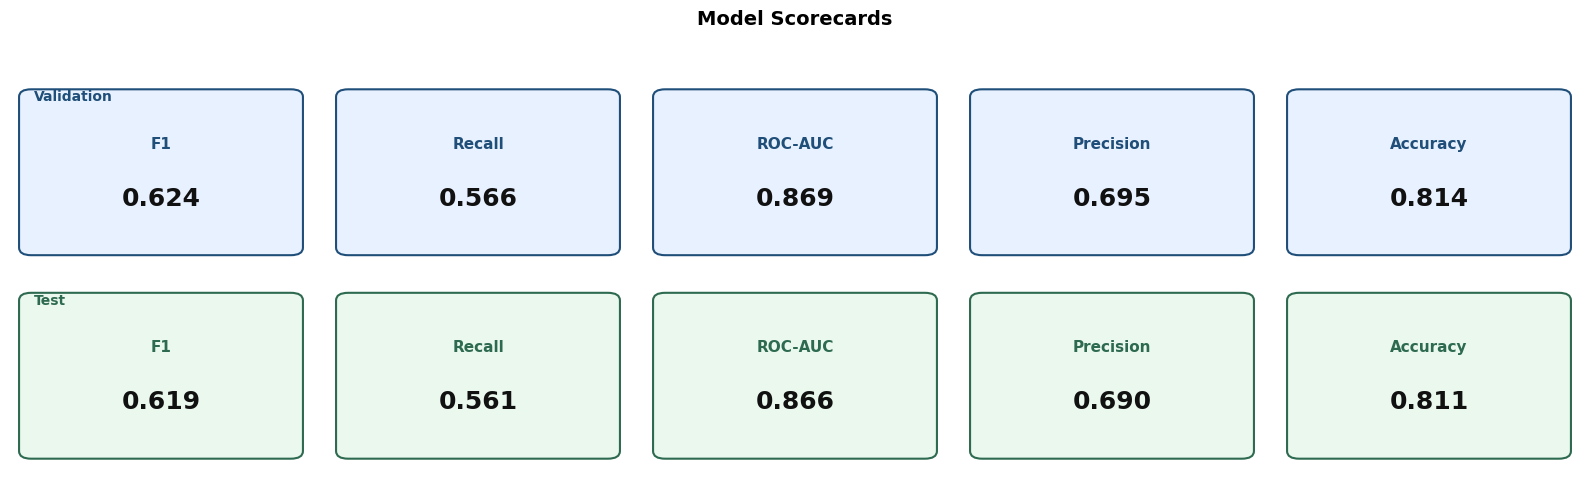

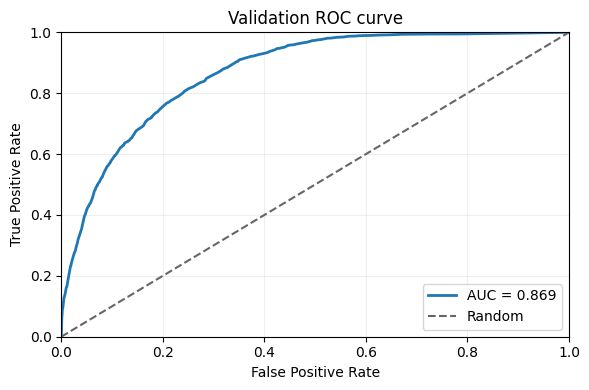

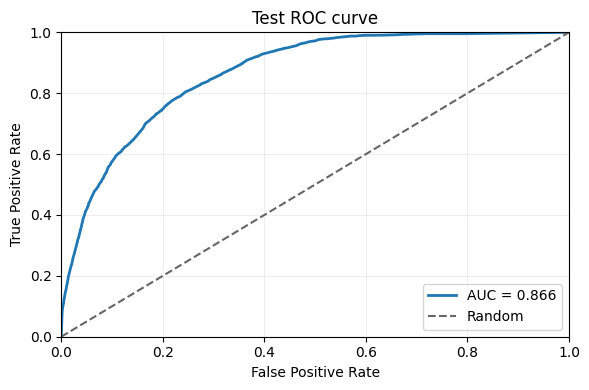

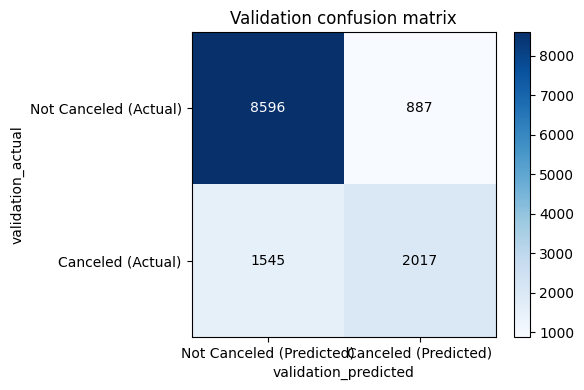

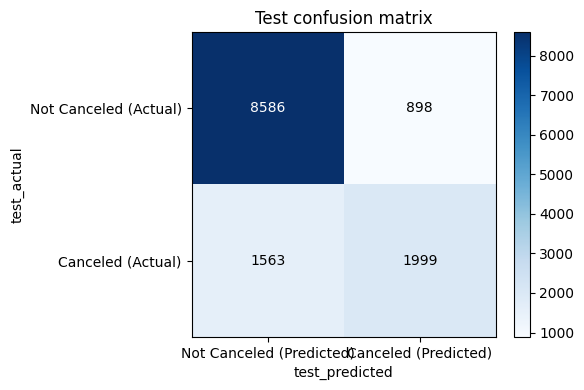

,split,accuracy,precision,recall,f1,roc_auc
0,validation,0.8136,0.6946,0.5663,0.6239,0.8691
1,test,0.8114,0.6900,0.5612,0.6190,0.8663


In [4]:
val_results = evaluate_classifier(best_dt, X_val, y_val, 'validation')
test_results = evaluate_classifier(best_dt, X_test, y_test, 'test')
plot_metric_scorecards(val_results, test_results)
plot_roc_curve(best_dt, X_val, y_val, 'validation')
plot_roc_curve(best_dt, X_test, y_test, 'test')
val_cm = get_confusion_matrix_df(best_dt, X_val, y_val, 'validation', plot=True)
test_cm = get_confusion_matrix_df(best_dt, X_test, y_test, 'test', plot=True)

results_df = pd.DataFrame([val_results, test_results])
display(results_df.round(4))

In [5]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_dt.feature_importances_,
}).sort_values('importance', ascending=False)

display(importance_df.head(15))

,feature,importance
31,country_PRT,0.158723
14,required_car_parking_spaces,0.126703
15,total_of_special_requests,0.091256
0,lead_time,0.063267
19,agent_9,0.052248
63,market_segment_Online TA,0.033796
11,booking_changes,0.029854
52,hotel_Resort Hotel,0.029115
49,total_cost,0.028234
4,stays_in_week_nights,0.026393
